# Equipo 3 - Perspectiva Estelar

In [1]:
import pandas as pd
from scipy.stats import pearsonr
import seaborn as sb

In [2]:
data = pd.read_csv("hwc.csv", usecols=["P_NAME", "P_HABITABLE", "S_TYPE", "S_TYPE_TEMP", "S_TEMPERATURE", "S_MASS", "S_RADIUS", "S_LOG_LUM",
"S_LOG_G", "S_AGE", "S_METALLICITY", "S_DISTANCE", "S_HZ_OPT_MIN", "S_HZ_OPT_MAX", "S_HZ_CON_MIN",
"S_HZ_CON_MAX", "S_TIDAL_LOCK", "S_SNOW_LINE", "S_ABIO_ZONE", "P_ESI"])
data

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
0,OGLE-2016-BLG-1227L b,NaN,NaN,NaN,0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.214133,0,NaN
1,Kepler-276 c,NaN,1144.8600,5779.0,1.10,1.03,0.02,0.40,-0.089,4.46,G,0.677337,1.595742,0.857931,1.512908,2.437046,2.097783,0.316980,0,0.272032
2,Kepler-829 b,NaN,1073.7600,5698.0,0.98,0.97,0.03,4.68,0.040,4.46,G,0.789603,1.864342,1.000132,1.767566,2.827247,1.756317,0.459559,0,0.254763
3,K2-283 b,NaN,402.9150,5060.0,0.89,0.82,0.28,NaN,-0.524,4.56,K,0.427216,1.030473,0.541131,0.976981,1.476943,0.568374,0.443760,0,0.193906
4,Kepler-477 b,NaN,367.0000,5240.0,0.87,0.79,-0.04,2.09,-0.372,4.58,K,0.504264,1.208168,0.638721,1.145452,1.759397,0.768502,0.386150,0,0.276721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5594,HD 222155 b,G2 V,50.6078,5701.0,1.21,1.85,-0.18,8.20,0.509,3.99,G,1.354663,3.198245,1.715852,3.032227,4.851363,1.893917,0.541322,0,0.178593
5595,HD 88986 b,G2 V,33.2673,5861.0,1.25,1.54,0.06,7.90,0.393,4.16,G,1.173962,2.759889,1.486965,2.616626,4.244864,2.520276,0.543834,0,0.379540
5596,Kepler-30 b,NaN,914.2210,5498.0,0.99,0.95,0.18,2.00,-0.237,4.77,G,0.580739,1.379360,0.735584,1.307759,2.055246,1.249824,0.400198,0,0.241771
5597,HD 3167 d,K0 V,47.2899,5261.0,0.84,0.88,0.04,7.80,-0.270,4.47,K,0.566466,1.356182,0.717509,1.285783,1.978626,0.787469,0.475336,0,0.272975


In [3]:
data.sort_values("P_ESI",ascending=False)

,P_NAME,S_TYPE,S_DISTANCE,S_TEMPERATURE,S_MASS,S_RADIUS,S_METALLICITY,S_AGE,S_LOG_LUM,S_LOG_G,S_TYPE_TEMP,S_HZ_OPT_MIN,S_HZ_OPT_MAX,S_HZ_CON_MIN,S_HZ_CON_MAX,S_SNOW_LINE,S_ABIO_ZONE,S_TIDAL_LOCK,P_HABITABLE,P_ESI
934,Teegarden's Star b,M7.0 V,3.830780,3034.0,0.10,0.12,-0.11,8.0,-3.141,5.19,M,0.022098,0.058638,0.027989,0.055592,0.072588,0.008444,0.234823,1,0.968362
537,TOI-700 d,M2.5 V,31.126500,3459.0,0.42,0.42,-0.07,1.5,-1.640,4.81,M,0.123856,0.322058,0.156882,0.305334,0.408662,0.028274,0.286631,1,0.941176
1291,Kepler-1649 c,NaN,92.191300,3240.0,0.20,0.23,-0.15,NaN,-2.287,5.00,M,0.058946,0.154913,0.074663,0.146868,0.194028,0.015156,0.269791,1,0.925298
480,TOI-700 e,M2.5 V,31.126500,3459.0,0.42,0.42,-0.07,1.5,-1.640,4.81,M,0.123856,0.322058,0.156882,0.305334,0.408662,0.028274,0.286631,1,0.912032
2239,TRAPPIST-1 d,NaN,12.429889,2566.0,0.09,0.12,0.04,0.5,-3.257,5.24,M,0.019438,0.052572,0.024620,0.049840,0.063513,0.003648,0.142824,1,0.907662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5575,OGLE-2019-BLG-0249L b,NaN,6370.000000,NaN,0.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.447059,0,NaN
5576,OGLE-2019-BLG-0679L b,NaN,5630.000000,NaN,0.66,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.401667,0,NaN
5591,KMT-2019-BLG-1216L b,NaN,2740.000000,NaN,0.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.337059,0,NaN
5593,KMT-2022-BLG-0440L b,NaN,3500.000000,NaN,0.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.373344,0,NaN


In [4]:
cols=data.columns.to_list()
cols=cols[2:10]+cols[11:-2]

In [5]:
corr=[]
for item in cols:
    clean=data[item].fillna(0)
    pe=pearsonr(clean,data["P_ESI"]).pvalue
    corr.append(pe)
corr

[np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan)]

In [56]:
data_esi=data[data["P_HABITABLE"]>=1]
var="S_AGE"

In [57]:
data_esi[var].describe()

count    49.000000
mean      3.891020
std       2.358261
min       0.400000
25%       2.000000
50%       4.000000
75%       6.000000
max       8.000000
Name: S_AGE, dtype: float64

In [58]:
import matplotlib.pyplot as plt

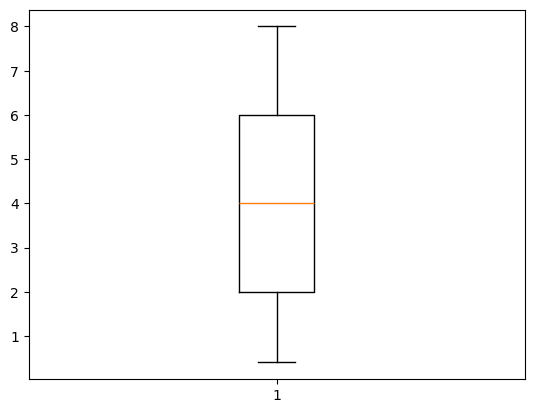

In [59]:
fig, ax = plt.subplots()
ax.boxplot(data_esi[var].dropna())
#ax.set(ylim=(0,14))
plt.show()

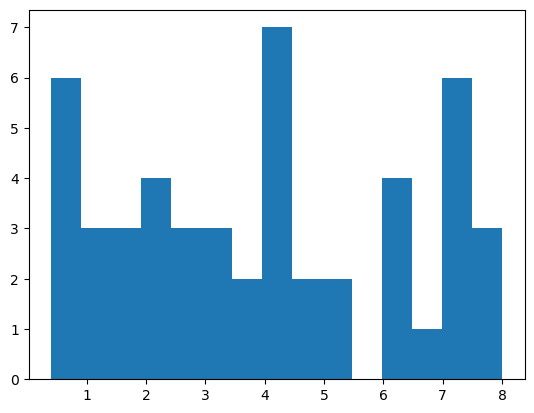

In [60]:
plt.hist(data_esi[var], bins=15)
plt.show()